# <center><strong> Bike Rental Analysis & Prediction </strong></center>
-------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

---------------------------

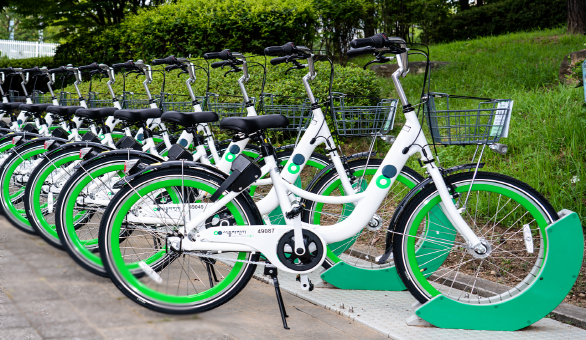

In [225]:
from IPython.display import Image
Image(filename='bi.png')

------------------------------

## <center><strong> Project Overview </strong></center>

#### **Bike share systems are a way to rent bikes where the process of obtaining membership, renting and returning bikes is automated through a network of kiosks located throughout the city. Through these systems, people can rent a bike from one location and return it to another location based on their needs. Currently, there are more than 500 bike share programs around the world.**

---------------------------------
---------------------------------
---------------------------------

## **Import Libraries** 

In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from datetime import datetime
import calendar 
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from math import sqrt
from pickle import dump, load

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

----------------------------
### **Initial fonction**
------------------------------

In [227]:
def countplot(data,col):
    sns.countplot(x=col, data=data)
    plt.xlabel('Year')
    plt.show()

def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.show()

def boxplot(data, col):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(8, 4)
    sns.boxplot(data=data,x=col,orient="o",ax=axes)
    plt.show()

def boxplot2(data, x,y):
    fig, axes = plt.subplots(nrows=1,ncols=1)
    fig.set_size_inches(10, 5)
    sns.boxplot(data=data,y=y,x=x,orient="v",ax=axes)
    plt.show()

def kde (data,col):
    plt.figure(figsize=(8,	4))
    sns.kdeplot(data[col], fill=True,	color='violet', alpha=0.6)
    plt.title(f'Kernel Density Estimate(KDE) - {col}',	fontsize=16)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

----------------------------------
----------------------------------

### **Initial Data Understanding**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

----------------------

In [228]:
df = pd.read_csv("Bike rental dataset.csv")
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [229]:
df.shape

(10886, 12)

In [230]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [231]:
df.rename(columns={'casual': 'non-subscribed_users', 
                   'registered':'subscribed_users', 
                   'count': 'count_of_users', 
                   'temp':'Actual_Temperature', 
                   'atemp':'Feels_Like_Temperature'} ,inplace=True)

In [232]:
df

,datetime,season,holiday,workingday,weather,Actual_Temperature,Feels_Like_Temperature,humidity,windspeed,non-subscribed_users,subscribed_users,count_of_users
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   datetime                10886 non-null  object 
 1   season                  10886 non-null  int64  
 2   holiday                 10886 non-null  int64  
 3   workingday              10886 non-null  int64  
 4   weather                 10886 non-null  int64  
 5   Actual_Temperature      10886 non-null  float64
 6   Feels_Like_Temperature  10886 non-null  float64
 7   humidity                10886 non-null  int64  
 8   windspeed               10886 non-null  float64
 9   non-subscribed_users    10886 non-null  int64  
 10  subscribed_users        10886 non-null  int64  
 11  count_of_users          10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [234]:
df.isnull().sum()

datetime                  0
season                    0
holiday                   0
workingday                0
weather                   0
Actual_Temperature        0
Feels_Like_Temperature    0
humidity                  0
windspeed                 0
non-subscribed_users      0
subscribed_users          0
count_of_users            0
dtype: int64

In [235]:
df.duplicated().sum()

0

-----------------------
-----------------------

### **Basic Statistical Overview**

---------------------------------

- #### Summary Statistical : **describe()**

In [236]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
Actual_Temperature,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
Feels_Like_Temperature,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
non-subscribed_users,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
subscribed_users,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [237]:
df.select_dtypes(include='object').describe()

,datetime
count,10886
unique,10886
top,2011-01-01 00:00:00
freq,1


-------------------------

## **Feature Extraction**

----------------------------

#### Extracting new column **[date]** from **[datetime]**

In [238]:
"2011-01-01 00:00:00".split()

['2011-01-01', '00:00:00']

In [239]:
df['datetime'][0].split()

['2011-01-01', '00:00:00']

In [240]:
df['datetime'][0].split()[0]

'2011-01-01'

In [241]:
df["date"] = df['datetime'].apply(lambda x : x.split()[0])

In [242]:
df['date'].head()

0    2011-01-01
1    2011-01-01
2    2011-01-01
3    2011-01-01
4    2011-01-01
Name: date, dtype: object

--------------------

#### Extracting new column **[time]** from **[dateime]**

In [243]:
df['datetime'][0].split()

['2011-01-01', '00:00:00']

In [244]:
df['datetime'][0].split()[1]

'00:00:00'

In [245]:
df['time'] = df['datetime'].apply(lambda x : x.split()[1])

In [246]:
df['time'].head()

0    00:00:00
1    01:00:00
2    02:00:00
3    03:00:00
4    04:00:00
Name: time, dtype: object

-------------------------------------

#### Extracting new column **[year]** from **[date]**

In [247]:
df['date'][0].split()[0]

'2011-01-01'

In [248]:
df['date'][0].split()[0].split('-')[0]

'2011'

In [249]:
df['year'] =df['date'].apply(lambda x : x.split()[0].split('-')[0])

In [250]:
df['year'] = df['year'].astype(int)

In [251]:
df['year'].value_counts()

year
2012    5464
2011    5422
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\1817585652.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette=['green','red'])


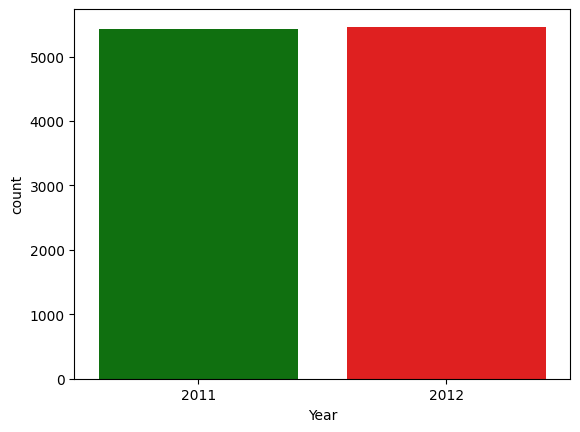

In [252]:
sns.countplot(x='year', data=df, palette=['green','red'])
plt.xlabel('Year')
plt.show()

-------------------------------

#### Extracting new column **[month]** from **[date]**

In [253]:
df['date'][0].split()[0]

'2011-01-01'

In [254]:
df['date'][0].split()[0].split('-')[1]

'01'

In [255]:
df['date'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%Y-%m-%d").month])

0         January
1         January
2         January
3         January
4         January
           ...   
10881    December
10882    December
10883    December
10884    December
10885    December
Name: date, Length: 10886, dtype: object

In [256]:
df["month"] = df['date'].apply(lambda x : calendar.month_name[datetime.strptime(x,"%Y-%m-%d").month])

In [257]:
df['month'].head()

0    January
1    January
2    January
3    January
4    January
Name: month, dtype: object

In [258]:
df['month'].value_counts()

month
May          912
June         912
July         912
August       912
December     912
October      911
November     911
April        909
September    909
February     901
March        901
January      884
Name: count, dtype: int64

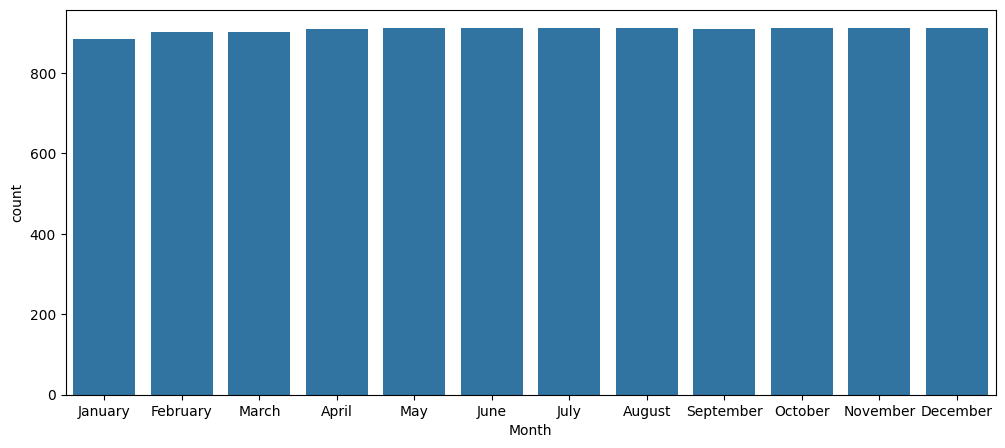

In [259]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='month', data=df)
plt.xlabel('Month')
plt.show()

------------------------

#### Extracting new column **[day]** from **[date]**

In [260]:
df['date'][0].split()[0]

'2011-01-01'

In [261]:
df['date'][0].split()[0].split('-')[2]

'01'

In [262]:
df['date'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%Y-%m-%d").weekday()])

0         Saturday
1         Saturday
2         Saturday
3         Saturday
4         Saturday
           ...    
10881    Wednesday
10882    Wednesday
10883    Wednesday
10884    Wednesday
10885    Wednesday
Name: date, Length: 10886, dtype: object

In [263]:
df["day"] = df['date'].apply(lambda x : calendar.day_name[datetime.strptime(x,"%Y-%m-%d").weekday()])

In [264]:
df["day"].head()

0    Saturday
1    Saturday
2    Saturday
3    Saturday
4    Saturday
Name: day, dtype: object

In [265]:
df["day"].value_counts()

day
Saturday     1584
Sunday       1579
Thursday     1553
Monday       1551
Wednesday    1551
Tuesday      1539
Friday       1529
Name: count, dtype: int64

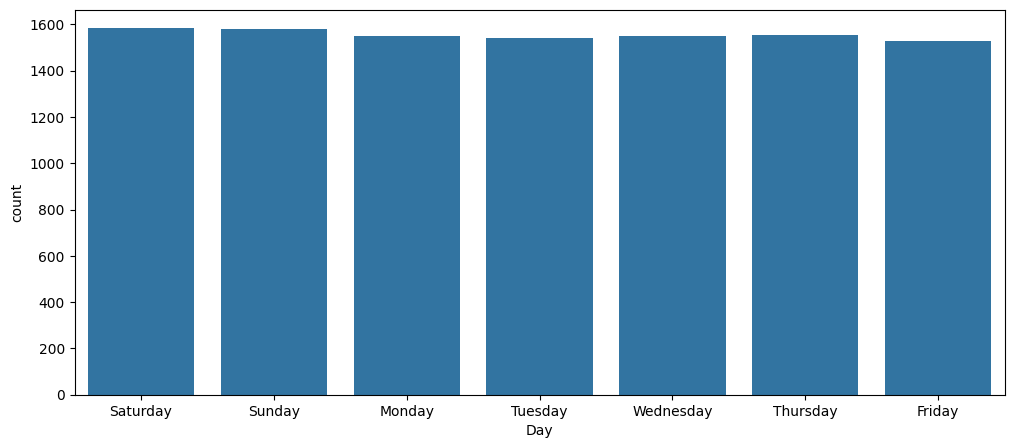

In [266]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='day', data=df)
plt.xlabel('Day')
plt.show()

------------------------

#### Extracting new column **[hour]** from **[time]**

In [267]:
df['time'][0]

'00:00:00'

In [268]:
df['time'][0].split(':')[0]

'00'

In [269]:
df['time'].apply(lambda x : x.split(":")[0])

0        00
1        01
2        02
3        03
4        04
         ..
10881    19
10882    20
10883    21
10884    22
10885    23
Name: time, Length: 10886, dtype: object

In [270]:
df["hour"] = df['time'].apply(lambda x : x.split(":")[0])

In [271]:
df['hour'].value_counts()

hour
12    456
13    456
22    456
21    456
20    456
19    456
18    456
17    456
16    456
15    456
14    456
23    456
11    455
10    455
09    455
08    455
07    455
06    455
00    455
01    454
05    452
02    448
04    442
03    433
Name: count, dtype: int64

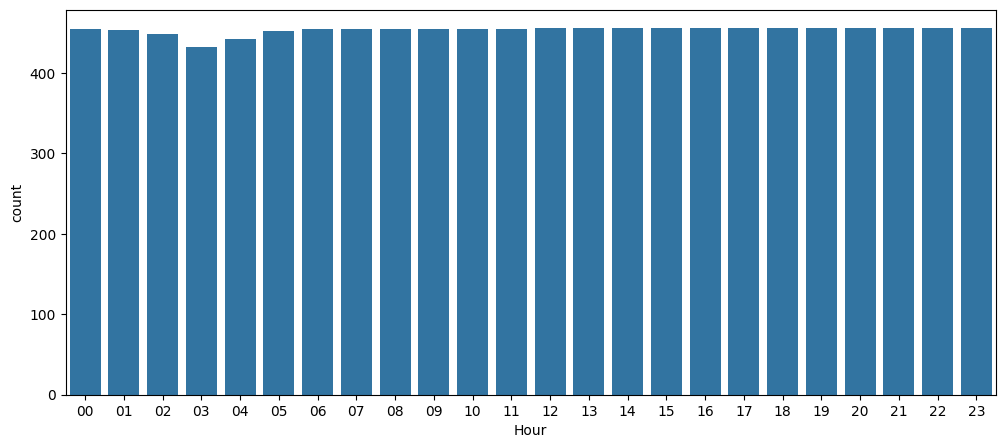

In [272]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='hour', data=df)
plt.xlabel('Hour')
plt.show()

------------------------

#### Extracting new column **[the_usual_time_periods_per_day]** from **[hour]**

In [273]:
df['hour'] = df['hour'].astype(int)

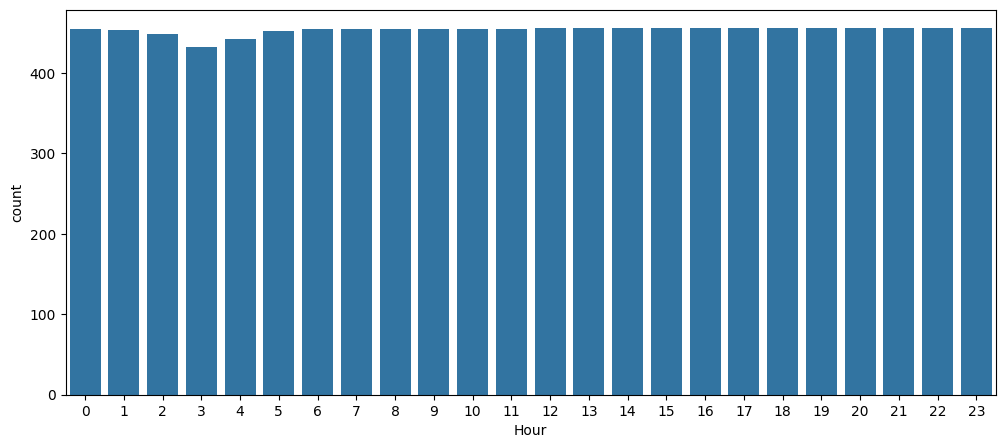

In [274]:
fig,ax= plt.subplots()
fig.set_size_inches(12,5)
sns.countplot(x='hour', data=df)
plt.xlabel('Hour')
plt.show()

In [275]:
def TheUsualTimePeriodsPerDay(hour):
    hour = int(hour)
    if 6 <= hour <= 11:
        return 'Morning'
    elif 12 <= hour <= 13:
        return 'Midday/Noon'
    elif 14 <= hour <= 17:
        return 'Afternoon'
    elif 18 <= hour <= 20:
        return 'Evening'
    elif 21 <= hour <= 23:
        return 'Night'
    else: 
        return 'Midnight and After'

df['the_usual_time_periods_per_day'] = df['hour'].apply(lambda x : TheUsualTimePeriodsPerDay(x))

In [276]:
df['the_usual_time_periods_per_day'].value_counts()

the_usual_time_periods_per_day
Morning               2730
Midnight and After    2684
Afternoon             1824
Evening               1368
Night                 1368
Midday/Noon            912
Name: count, dtype: int64

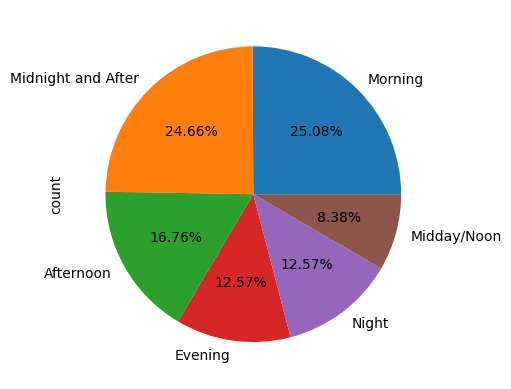

In [277]:
df['the_usual_time_periods_per_day'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

-----------------------

#### Extracting new column **[weather_feeling]** from **[Feels_Like_Temperature]**

In [278]:
df['Feels_Like_Temperature'].unique()

array([14.395, 13.635, 12.88 , 17.425, 19.695, 16.665, 21.21 , 22.725,
       21.97 , 20.455, 11.365, 10.605,  9.85 ,  8.335,  6.82 ,  5.305,
        6.06 ,  9.09 , 12.12 ,  7.575, 15.91 ,  3.03 ,  3.79 ,  4.545,
       15.15 , 18.18 , 25.   , 26.515, 27.275, 29.545, 23.485, 25.76 ,
       31.06 , 30.305, 24.24 , 18.94 , 31.82 , 32.575, 33.335, 28.79 ,
       34.85 , 35.605, 37.12 , 40.15 , 41.665, 40.91 , 39.395, 34.09 ,
       28.03 , 36.365, 37.88 , 42.425, 43.94 , 38.635,  1.515,  0.76 ,
        2.275, 43.18 , 44.695, 45.455])

In [279]:
def classify_temperature(FeelsLikeTemperature):
    
    if FeelsLikeTemperature < 0:
        return 'Freezing Cold'
    elif FeelsLikeTemperature < 11:
        return 'Cold'
    elif FeelsLikeTemperature < 21:
        return 'Cool'
    elif FeelsLikeTemperature < 26:
        return 'Mild'
    elif FeelsLikeTemperature < 31:
        return 'Warm'
    elif FeelsLikeTemperature < 36:
        return 'Hot'
    else:
        return 'Extremely Hot'

df['weather_feeling'] = df['Feels_Like_Temperature'].apply(lambda x : classify_temperature(x))

In [280]:
df['weather_feeling'].value_counts()

weather_feeling
Cool             3329
Mild             2375
Hot              2272
Warm             1539
Cold              743
Extremely Hot     628
Name: count, dtype: int64

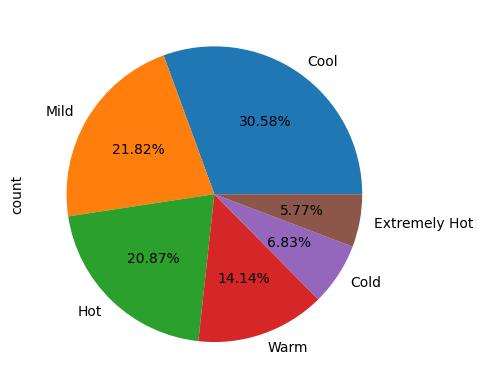

In [281]:
df['weather_feeling'].value_counts().plot.pie(autopct='%0.2f%%')
plt.show()

------------------------

#### Mapping **season column**

In [282]:
df['season'].value_counts()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

In [283]:
dictionnaire_saisons = {1 :"Winter" , 2: "Spring", 3 : "Summer", 4 : "Fall"}
df["season"] = df["season"].map(dictionnaire_saisons)


In [284]:
df['season'].value_counts()

season
Fall      2734
Spring    2733
Summer    2733
Winter    2686
Name: count, dtype: int64

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\3045485625.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='season', data=df, palette=['green','red','yellow','blue'])


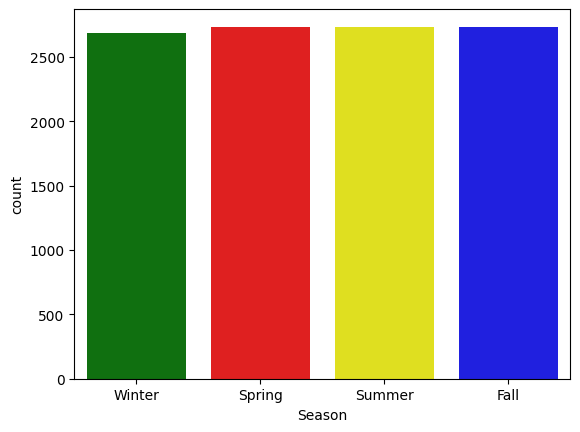

In [285]:
sns.countplot(x='season', data=df, palette=['green','red','yellow','blue'])
plt.xlabel('Season')
plt.show()

----------------------------------

#### Mapping **weather column**

##### Clear + Few clouds + Partly cloudy + Partly cloudy ----> **Clear to Partly Cloudy**
##### Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist ----> **Mist and Cloudy**
##### Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds" ----> **Light Precipitation**
##### Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog ----> **Severe Weather**

In [286]:
df["weather"].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

In [287]:
df["weather"] = df["weather"].map({1: "Clear to Partly Cloudy",\
                                        2 : "Mist and Cloudy", \
                                        3 : "Light Precipitation", \
                                        4 :"Severe Weather" })

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\1604790228.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='weather', data=df, palette=['green','red','yellow','blue'])


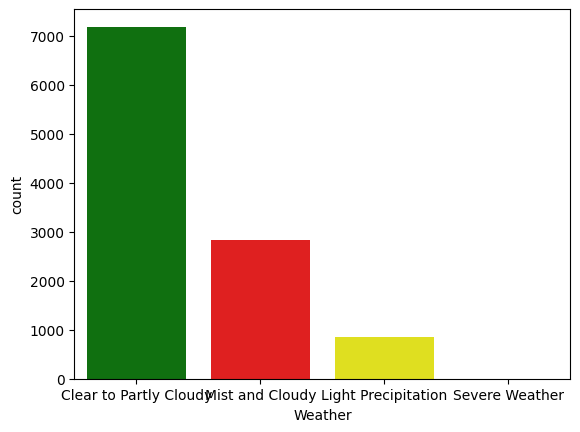

In [288]:
sns.countplot(x='weather', data=df, palette=['green','red','yellow','blue'])
plt.xlabel('Weather')
plt.show()

----------------------------------
#### Mapping **holiday column**

In [289]:
df["holiday"] = df["holiday"].map({0: "no", 1: "yes"})

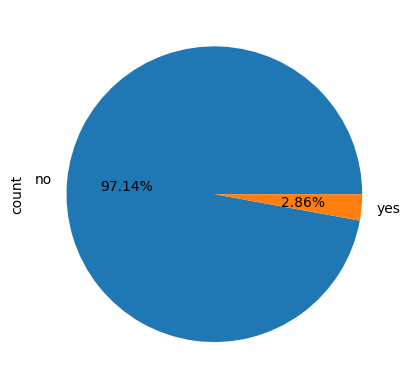

In [290]:
pie(df,'holiday')

------------------------------------
## **EDA**
------------------------------------

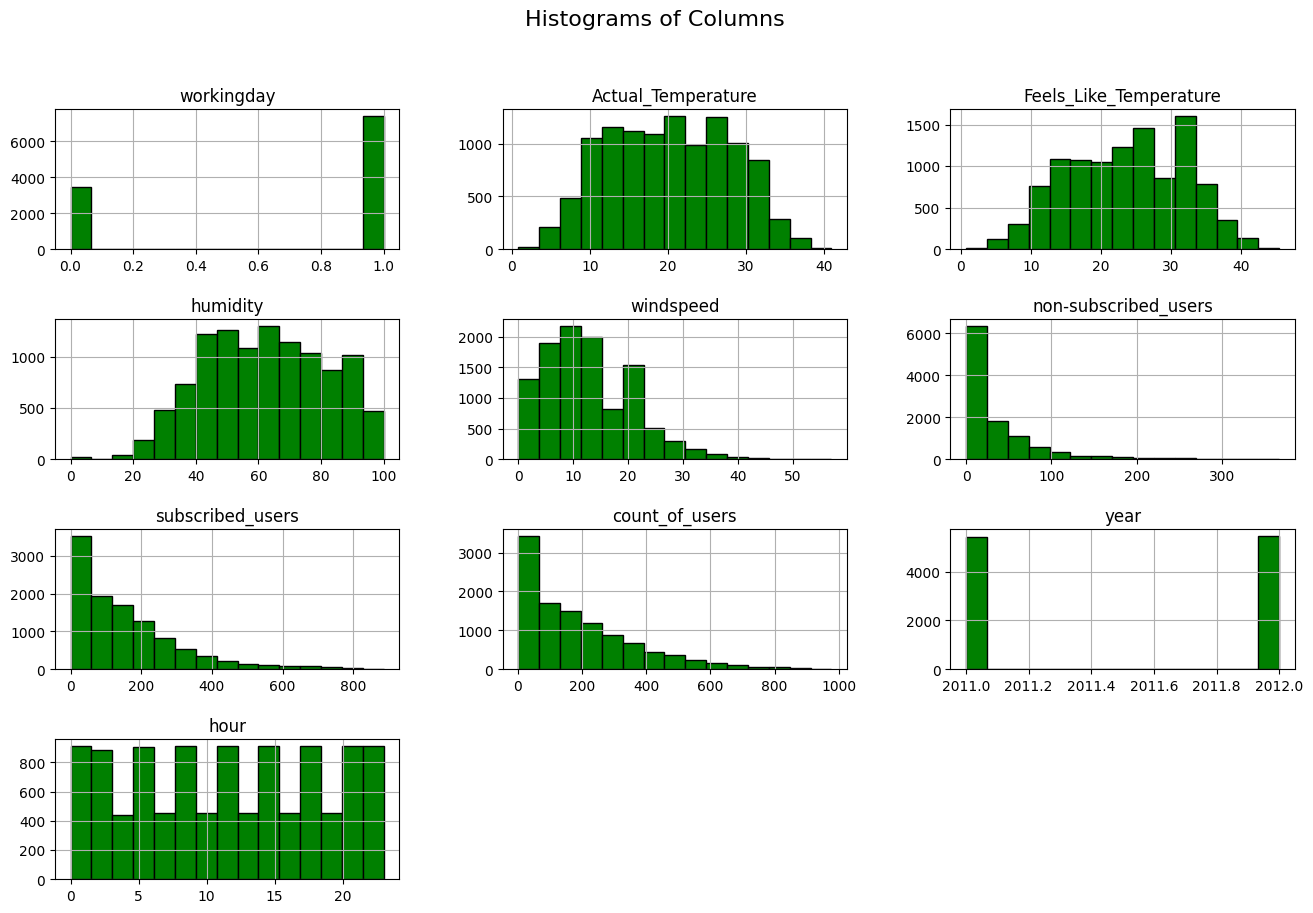

In [291]:
df.select_dtypes('number').hist(bins=15, figsize=(16, 10), color='green', edgecolor='black')

plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5) 
plt.show()

- ### **Correlation**

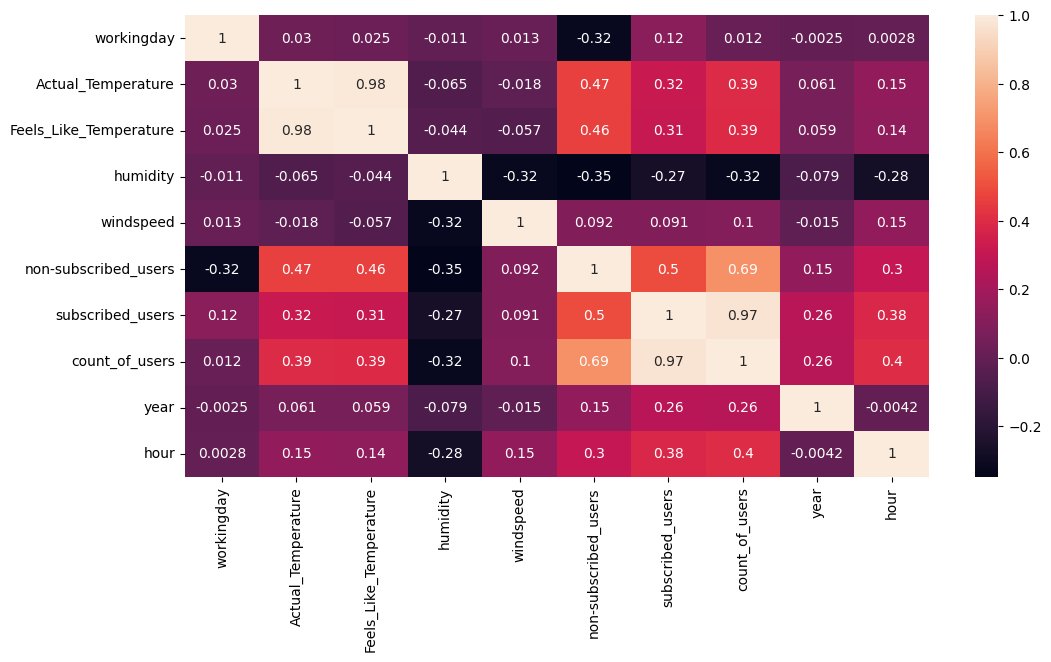

In [292]:
plt.figure(figsize=(12,	6))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

#### **1. Customer Types and Pricing Plan (User Types vs. Working Days)**
##### There is a moderate negative correlation (-0.32) between working days and non-subscribe users, compared to a positive correlation (0.12) with subscribes users.

##### Business Interpretation : Members rely on bicycles as a primary and economical means of transportation to work and university. non-subscribe users (tourists and leisure travelers) avoid the financially draining traffic of workdays (based on hourly rates) and prefer recreational rentals on weekends and holidays.

#### **2. Weather Impact:**
##### Temperature is the biggest driver of occupancy rates, and its correlation with the non-subscribe users (0.47) is stronger than with the subscribe users (0.32).

##### Business Interpretation : The leisure user is very sensitive to weather conditions and will only rent during warm weather (spring and summer), while the subscribe users is obligated to stay even on cold days due to work requirements. A logical inverse correlation (-0.32) was also observed between humidity and wind speed.

#### **3. Hourly Demand Dynamics**
##### There is a general positive correlation (0.4) between the hours of the day and the number of users.

##### Business Interpretation : Demand is negligible in the early morning hours (1 to 5 AM) because most users are asleep, and it gradually increases as the day progresses. (The relationship here is non-linear and follows the morning and evening peak demand curves.)

- ### **Count of users Distribution**

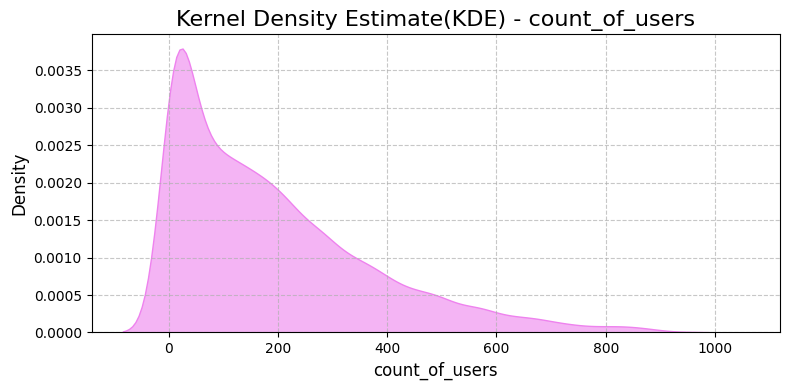

In [293]:
kde(df,'count_of_users')

##### This distribution tells us that our business is generally stable at low to medium rates most of the time (the large pink block on the left), but we do have 'explosive peak seasons' (the long tail extending to the right towards 600 and 800 users). These peaks don't always occur, but when they do, they pull the company's overall average up.


- ### **boxplot of count of users**


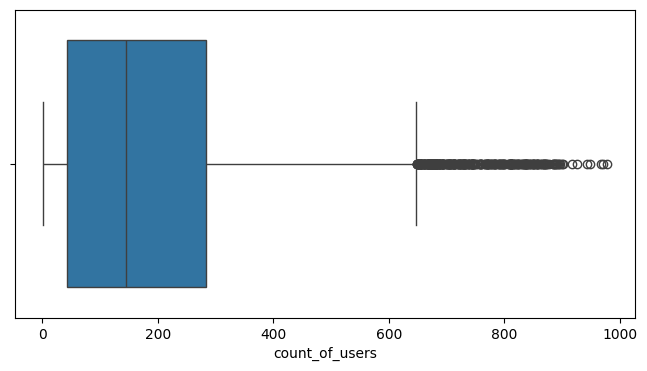

In [294]:
boxplot(df,'count_of_users')


- ### **boxplot of count of users vs categorical features**


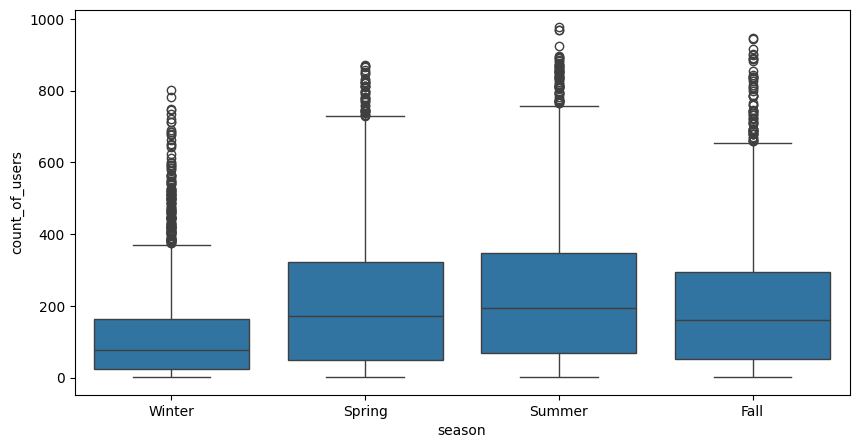

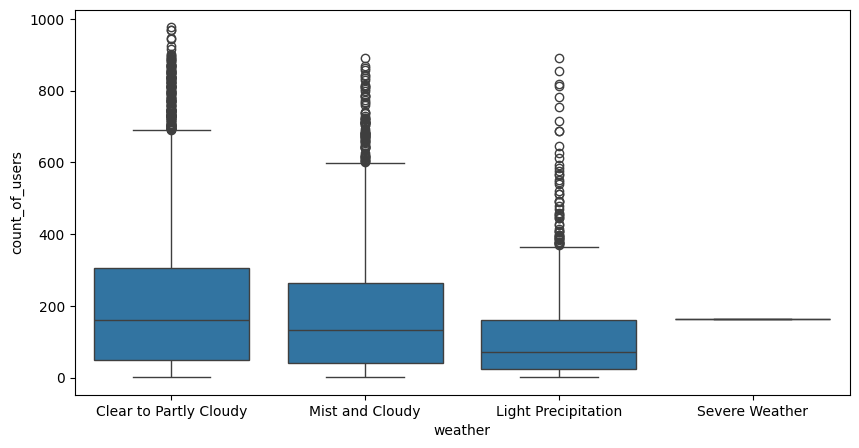

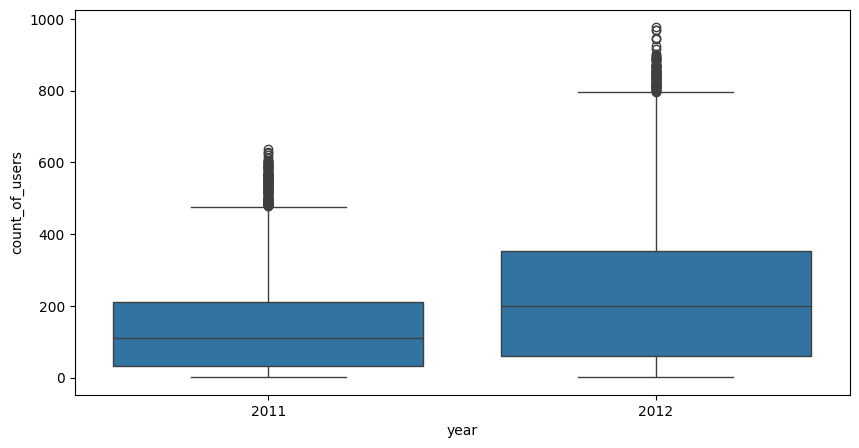

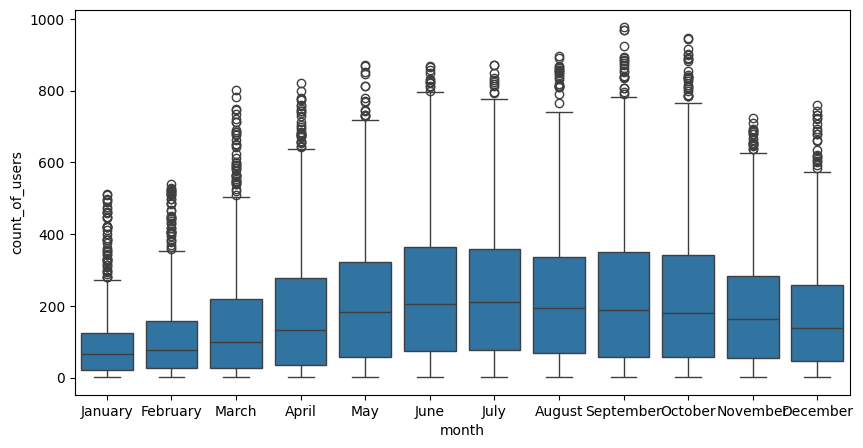

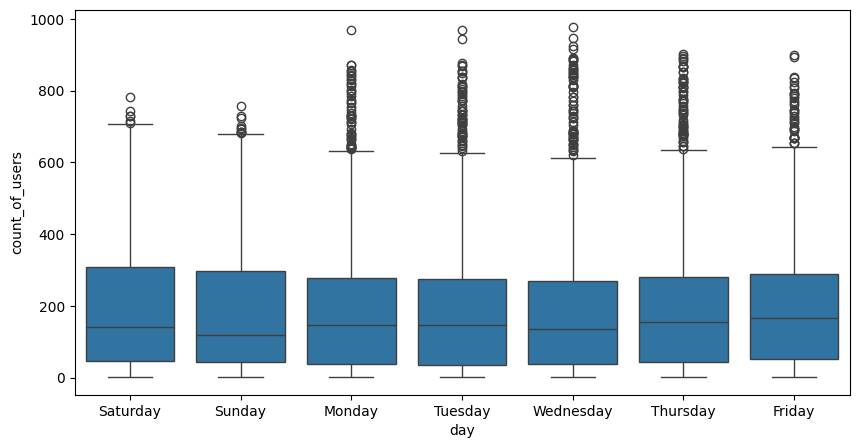

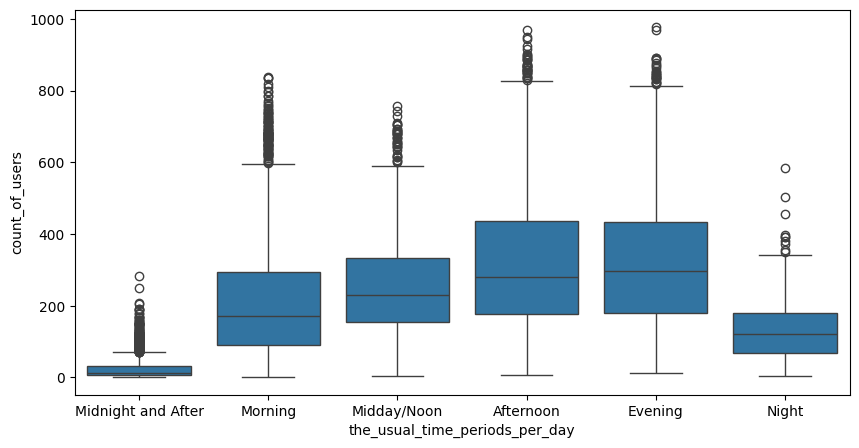

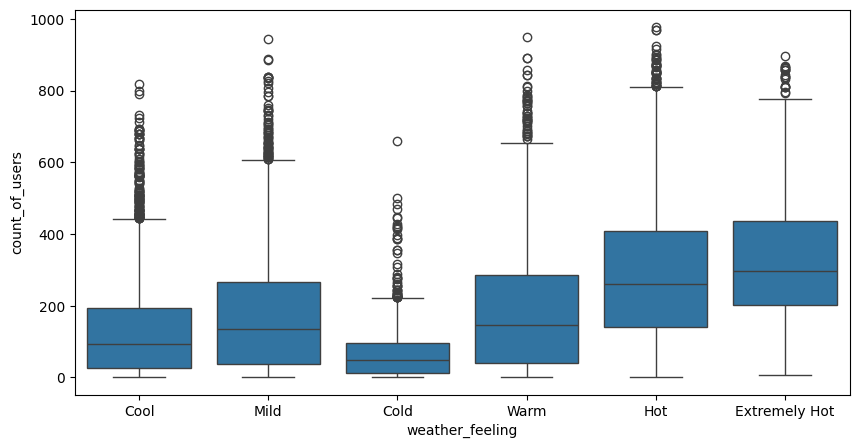

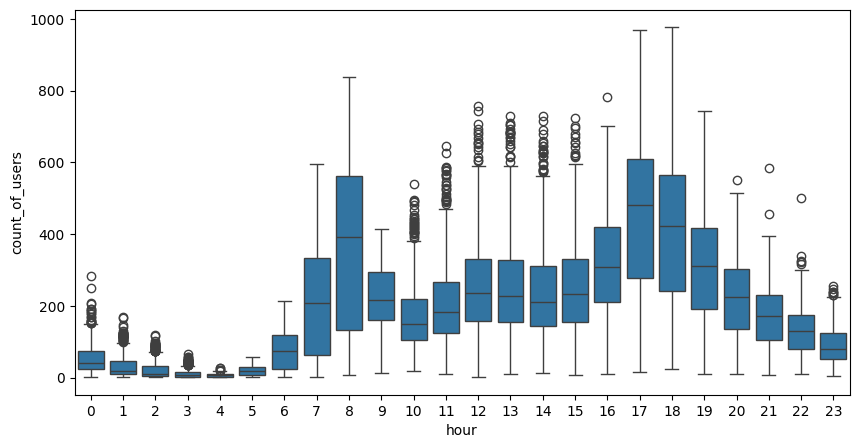

In [295]:
colscat = ['season','weather','year', 'month', 'day', 'the_usual_time_periods_per_day', 'weather_feeling','hour']
for col in colscat:
    boxplot2(df,col,'count_of_users')

-----------------------

In [296]:
# df.to_excel('Bake rental (New data).xlsx',index=False)

--------------------------------
------------------------------

## **Hypothesis Testing Analysis**

---------------------------------
- #### **holidays and working days vs count of users & non subscribed users**
---------------------------------- 

In [297]:
# count of users column is not normal distribution
workday_users = df[df['holiday'] == 'no']['count_of_users']
holiday_users = df[df['holiday'] == 'yes']['count_of_users']

stat, p_value = stats.mannwhitneyu(workday_users, holiday_users)

print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value: 0.864636
There is not a significant difference ---> H0 is not rejacted


In [298]:
non_sub_workday = df[df['holiday'] == 'no']['non-subscribed_users']
non_sub_holiday = df[df['holiday'] == 'yes']['non-subscribed_users']

stat_sub, p_value_sub = stats.mannwhitneyu(non_sub_workday, non_sub_holiday)
print(f"p-value : {p_value_sub:.6f}")

if p_value_sub < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value : 0.003708
There is a significant difference ---> H0 is rejected


##### Looking only at the total number of users, we might mistakenly believe that holidays don't affect our count of users (p=0.86). However, after further analysis, we discovered that this apparent similarity is a statistical illusion. A very active segment during holidays is non-subscriber users, and our tests revealed a significant and noticeable difference in their behavior (p=0.0037).

##### Business Recommendation : Holidays see a massive influx of users (tourists and vacationers). We should raise our individual rental rates (per hour) on weekends to maximize profits and offer them a discount code at the end of the day to convert them into "regular subscribers" who will serve us during the week!

---------------------------------
- #### **year vs count of users**

In [299]:
y_2011 = df[df['year'] == 2011]['count_of_users']
y_2012 = df[df['year'] == 2012]['count_of_users']

stat, p_value = stats.mannwhitneyu(y_2011, y_2012)
print(f"p-value : {p_value:.6f}")

if p_value < 0.05:
    print("There is a significant difference ---> H0 is rejected")
else :
    print("There is not a significant difference ---> H0 is not rejacted")

p-value : 0.000000
There is a significant difference ---> H0 is rejected


C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\918418359.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["year"], data=hourAggregated, join=True,ax=ax)


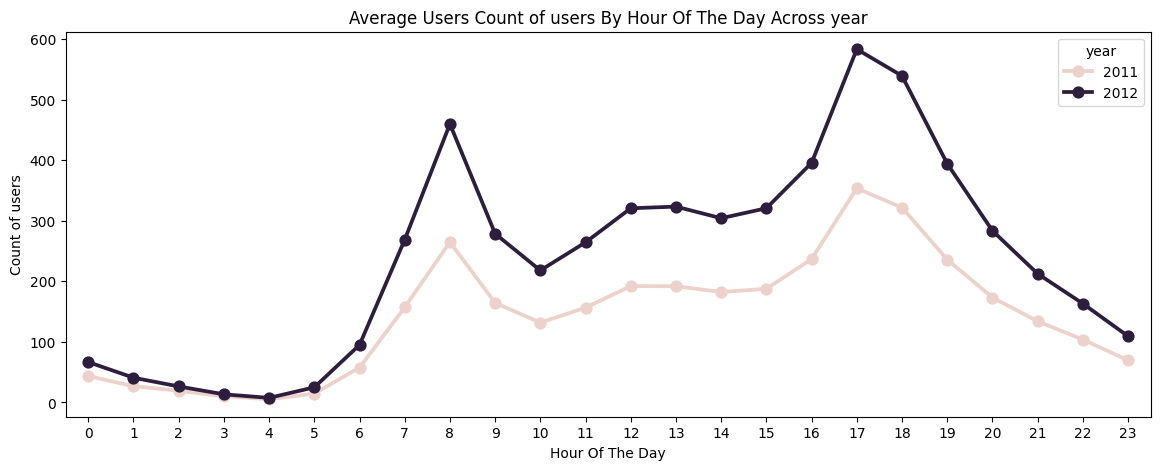

In [300]:
hourAggregated = pd.DataFrame(df.groupby(["hour","year"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["year"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across year",label='big')
plt.show()

##### Annual growth: The company experienced a real and proven leap and growth between 2011 and 2012, which means that the service is expanding over time and is not stagnant.

-----------------------------
- #### **season vs count of users**


In [301]:
fall = df[df['season']=='Fall']['count_of_users']
spring = df[df['season']=='Spring']['count_of_users']
summer = df[df['season']=='Summer']['count_of_users']
winter = df[df['season']=='Winter']['count_of_users']

In [302]:
def Shapiro(season):
    stat, p = stats.shapiro(season)

    print(f'Shapiro-Wilk Statistic: {stat:.4f}, P-value: {p:.4f}')
    
    if p > 0.05:
        print("The group follows a normal distribution (ANOVA)")
    else :
        print("The group does not follow the normal distribution (Kruskal-Wallis)")

In [303]:
season = [fall,spring,summer,winter]
for s in season:
    Shapiro(s)
    print('----------------------------------------------------')

Shapiro-Wilk Statistic: 0.8955, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------
Shapiro-Wilk Statistic: 0.9005, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------
Shapiro-Wilk Statistic: 0.9148, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------
Shapiro-Wilk Statistic: 0.8087, P-value: 0.0000
The group does not follow the normal distribution (Kruskal-Wallis)
----------------------------------------------------


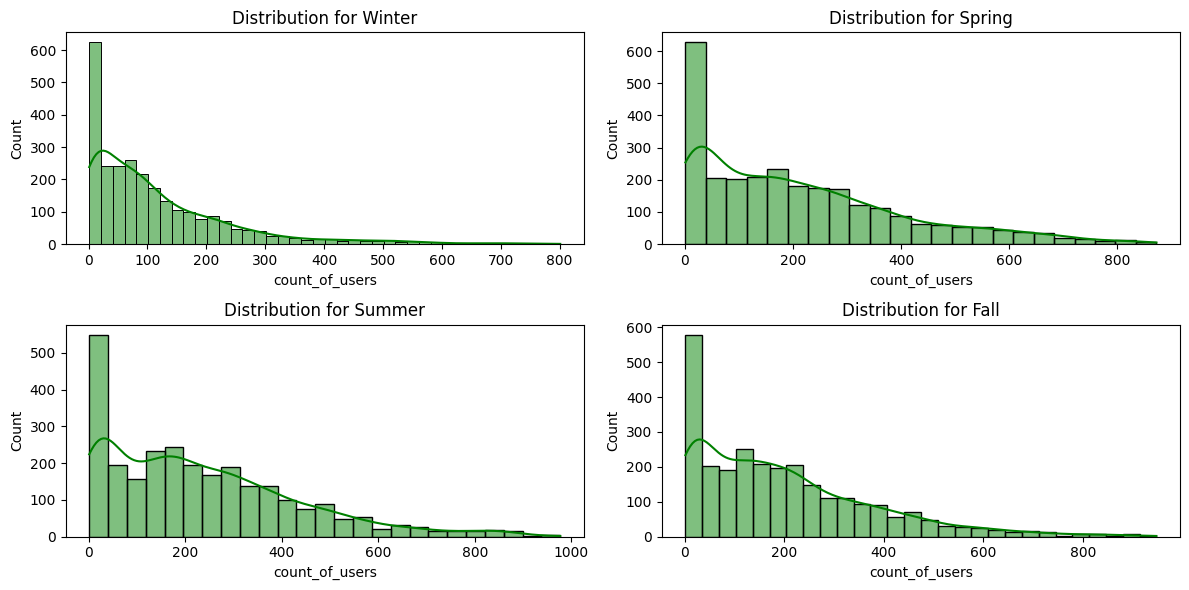

In [304]:
groups = df['season'].unique()

plt.figure(figsize=(12, 6))

for i, group in enumerate(groups):
    data_group = df[df['season'] == group]['count_of_users']
    
    plt.subplot(2, 2, i+1)
    sns.histplot(data_group, kde=True, color='green')
    plt.title(f'Distribution for {group}')

plt.tight_layout()
plt.show()

In [305]:
stat, p_value_k = stats.kruskal(fall, spring, summer, winter)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 699.6668548181915
P-value: 2.4790083726176776e-151
There is a significant difference


##### Weather seasons are not just names; they are the primary drivers of demand in our company. The differences between the seasons are real and scientifically proven, which necessitates that we completely abandon the idea of ​​a 'fixed budget year-round.'

##### Business recommendations based on the results:

- ##### Fleet Management: During peak seasons (which we will define in the next step, such as spring and summer), 100% of the bicycle fleet should be operational, and field maintenance teams should be intensified to redistribute bicycles among stations due to the surge in demand.

- ##### Dynamic Budgeting: Reduce advertising, marketing, and bicycle maintenance spending during off-peak seasons (winter and inclement weather), and free up these funds to be injected heavily a few weeks before the start of the peak season to attract the largest number of new customers.

--------------------------------
- #### **day vs count of users**

In [306]:
Sunday = df[df['day']=='Sunday']['count_of_users']
Monday = df[df['day']=='Monday']['count_of_users']
Tuesday = df[df['day']=='Tuesday']['count_of_users']
Wednesday = df[df['day']=='Wednesday']['count_of_users']
Thursday = df[df['day']=='Thursday']['count_of_users']
Friday = df[df['day']=='Friday']['count_of_users']
Saturday = df[df['day']=='Saturday']['count_of_users']

In [307]:
stat, p_value_k = stats.kruskal(Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value_k}")

if p_value_k < 0.05:
    print("There is a significant difference")
else :
    print("There is not a significant difference")

Kruskal-Wallis Statistic: 18.30682858506734
P-value: 0.005509463320287259
There is a significant difference


##### Scientifically, the seven days of the week do not yield the same returns (p=0.0055). Operating activity and tenant behavior are reshaped daily throughout the week.

##### Business Recommendation : We suggest implementing a dynamic pricing strategy, whereby the hourly rental rate is automatically adjusted based on the day's pattern (e.g., preferential rates on off-peak days midweek to encourage occupancy, and higher operating rates on peak days like weekends to maximize profits).

-------------------------------
- #### **Average Users Count By day Across season**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\3352596220.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=dayAggregated["day"], y=dayAggregated["count_of_users"],hue=dayAggregated["season"], data=dayAggregated, join=True,ax=ax)


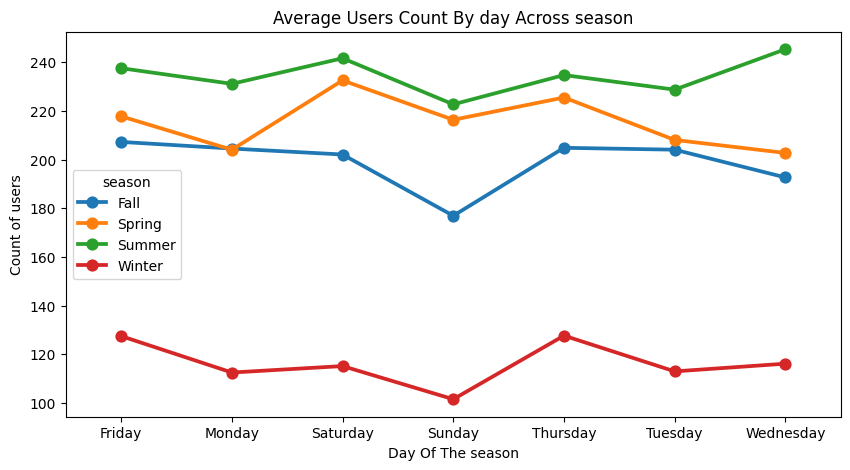

In [308]:
dayAggregated = pd.DataFrame(df.groupby(["season","day"],sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(10,5)
sns.pointplot(x=dayAggregated["day"], y=dayAggregated["count_of_users"],hue=dayAggregated["season"], data=dayAggregated, join=True,ax=ax)
ax.set(xlabel='Day Of The season', ylabel='Count of users',title="Average Users Count By day Across season",label='big')
plt.show()

##### The four seasons' lines are parallel, but they all undulate and descend on Sunday. This means that the "Sunday" effect has a different commercial weight if it is in the summer (when rents remain relatively high) compared to the winter (when it collapses completely close to 100).

----------------------------------
- #### **Hours and season groub by mean of count of users**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\1399915906.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax)


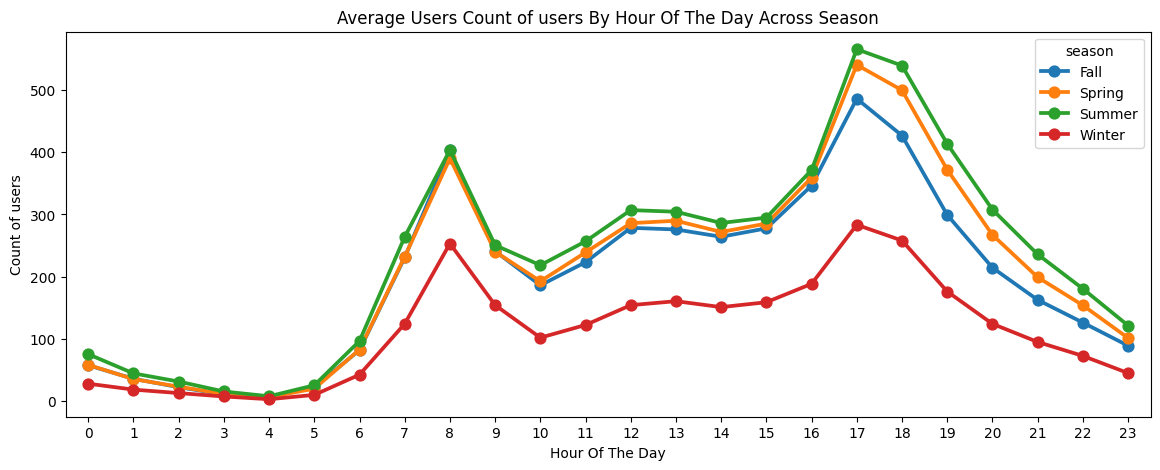

In [309]:
hourAggregated = pd.DataFrame(df.groupby(["hour","season"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["season"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across Season",label='big')
plt.show()

##### Clear Daily and Seasonal Patterns : The plot clearly shows distinct daily cycles of user activity, with significant differences between seasons.

##### Two Peaks in User Activity : For most seasons, there appear to be two main peaks in user activity: one in the morning/late morning and another, more prominent, in the late afternoon/early evening.

##### Lowest Activity in Early Morning : User counts are consistently lowest across all seasons in the very early morning hours (approximately 1 AM to 5 AM).

---------------------------------
- #### **Hours and day groub by mean of count of users**

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\3934328612.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["day"], data=hourAggregated, join=True,ax=ax)


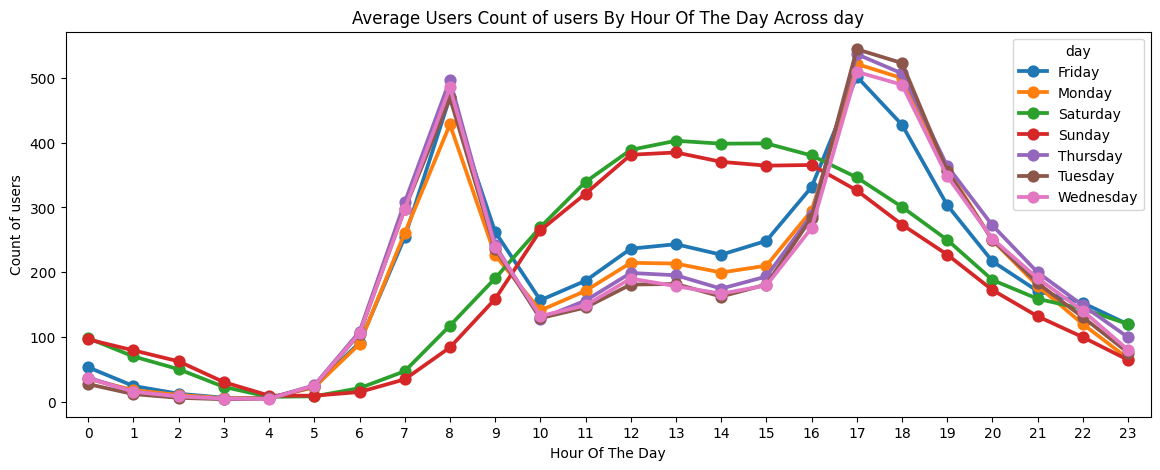

In [310]:
hourAggregated = pd.DataFrame(df.groupby(["hour","day"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["day"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across day",label='big')
plt.show()

-----------------------------------
## **Important Features**
-----------------------------------

##### Human movement follows a double bell curve (explosion in the morning when going to work, and in the evening when returning).

C:\Users\RPC\AppData\Local\Temp\ipykernel_18528\3409326351.py:5: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["workingday"], data=hourAggregated, join=True,ax=ax)


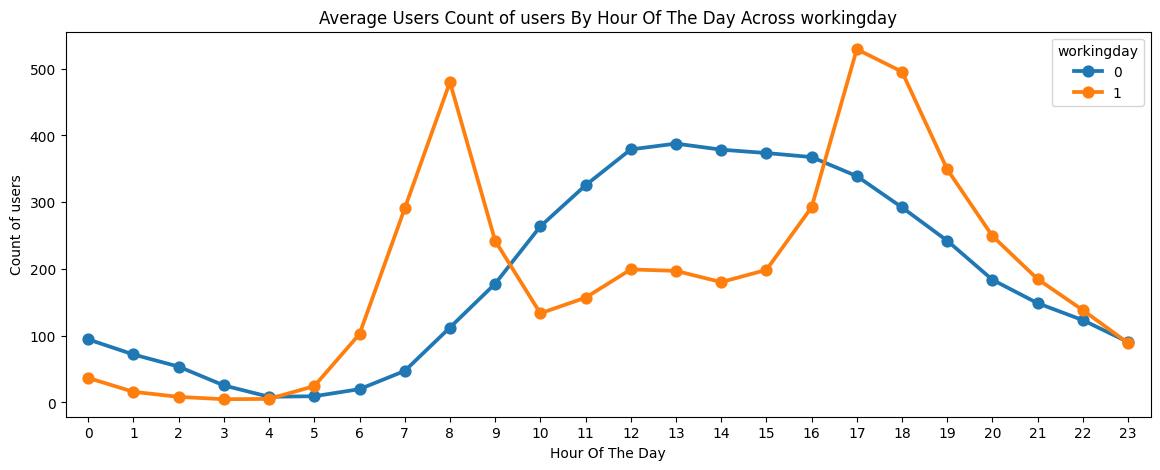

In [311]:
hourAggregated = pd.DataFrame(df.groupby(["hour","workingday"], sort=True)["count_of_users"].mean()).reset_index()

fig,ax= plt.subplots()
fig.set_size_inches(14,5)
sns.pointplot(x=hourAggregated["hour"], y=hourAggregated["count_of_users"],hue=hourAggregated["workingday"], data=hourAggregated, join=True,ax=ax)
ax.set(xlabel='Hour Of The Day', ylabel='Count of users',title="Average Users Count of users By Hour Of The Day Across workingday",label='big')
plt.show()

In [312]:
workday_peaks = [7, 8, 9, 16, 17, 18, 19]
df['is_workday_peak'] = ((df['workingday'] == 1) & (df['hour'].isin(workday_peaks))).astype(int)

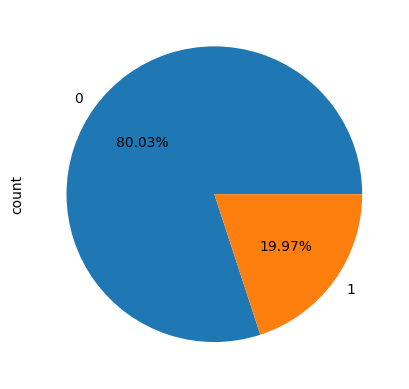

In [313]:
pie(df,'is_workday_peak')

In [314]:
weekend_peaks = [10,11, 12, 13, 14, 15, 16, 17, 18]
df['is_weekend_peak'] = ((df['workingday'] == 0) & (df['hour'].isin(weekend_peaks))).astype(int)

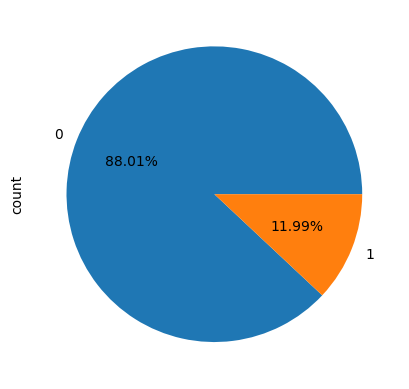

In [315]:
pie(df,'is_weekend_peak')

---------------------------------
--------------------------------

## **Machine Learning model**

-----------------------

In [316]:
df2 = df[['season', 'holiday', 'workingday', 'weather',
       'Actual_Temperature', 'humidity', 'windspeed',
       'count_of_users', 'year','month', 'day', 'hour',
       'the_usual_time_periods_per_day', 'weather_feeling',
       'is_workday_peak', 'is_weekend_peak']]

In [317]:
x = df2.drop('count_of_users',axis=1)
y = df2['count_of_users']
y_log = np.log1p(df['count_of_users'])

In [318]:
x_train, x_test, y_train, y_test = train_test_split(x,y,train_size=0.85,random_state=1234)
print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_test : {x_test.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_test : {y_test.shape}')

shape of x_train : (9253, 15)
shape of x_test : (1633, 15)
-------------------------------
shape of y_train : (9253,)
shape of y_test : (1633,)


In [319]:
RandomForestRegressor_model = RandomForestRegressor()
XGBRegressor_model = XGBRegressor()
LGBMRegressor_model	= LGBMRegressor()
CatBoostRegressor_model = CatBoostRegressor()

In [320]:
ordered_categories = [
                        ['Winter', 'Spring', 'Summer', 'Fall'],             
                        ['no','yes'],
                        ['Clear to Partly Cloudy','Mist and Cloudy','Light Precipitation','Severe Weather'],
                        ['January','February','March','April','May','June','July','August','September','October','November','December'],
                        ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
                        ['Midnight and After', 'Morning', 'Midday/Noon', 'Afternoon', 'Evening', 'Night'],
                        ['Cold', 'Cool', 'Mild','Warm','Hot','Extremely Hot']]

ordinal_cols = ['season', 'holiday', 'weather','month', 'day', 'the_usual_time_periods_per_day', 'weather_feeling']
ordinal_Encoder_pipeline = Pipeline(steps=[("encoder", OrdinalEncoder(categories = ordered_categories, handle_unknown="use_encoded_value",unknown_value=-1))])


num_cols = ['Actual_Temperature','humidity','windspeed','hour','year']
numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ("ord", ordinal_Encoder_pipeline, ordinal_cols)
        ])

In [321]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Actual_Temperature', 'humidity', 'windspeed',
                                  'hour', 'year']),
                                ('ord',
                                 Pipeline(steps=[('encoder',
                                                  OrdinalEncoder(categories=[['Winter',
                                                                              'Spring',
                                                                              'Summer',
                                                                              'Fall'],
                                                                             ['no',
                                                                              'yes'],
                                                                             ['Clear '
                                                                              'to '
                                                                              'Partly '
                                                                              'Cloudy',
                                                                              'Mist '
                                                                              'and '
                                                                              'Cloudy',
                                                                              'Light '
                                                                              'Precipitation',
                                                                              'Severe '
                                                                              'Weather'],
                                                                             ['J...
                                                                              'Tuesday',
                                                                              'Wednesday',
                                                                              'Thursday',
                                                                              'Friday',
                                                                              'Saturday',
                                                                              'Sunday'],
                                                                             ['Midnight '
                                                                              'and '
                                                                              'After',
                                                                              'Morning',
                                                                              'Midday/Noon',
                                                                              'Afternoon',
                                                                              'Evening',
                                                                              'Night'],
                                                                             ['Cold',
                                                                              'Cool',
                                                                              'Mild',
                                                                              'Warm',
                                                                              'Hot',
                                                                              'Extremely '
                                                                              'Hot']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1))]),
                              

In [322]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('RandomForestRegressor_model', RandomForestRegressor())])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('XGBRegressor_model', XGBRegressor())])

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('LGBM_model', LGBMRegressor(objective='regression'))])

cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('CatBoost_model', CatBoostRegressor(verbose=0))])

In [323]:
rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Actual_Temperature',
                                                   'humidity', 'windspeed',
                                                   'hour', 'year']),
                                                 ('ord',
                                                  Pipeline(steps=[('encoder',
                                                                   OrdinalEncoder(categories=[['Winter',
                                                                                               'Spring',
                                                                                               'Summer',
                                                                                               'Fall'],
                                                                                              ['no',
                                                                                               'yes'],
                                                                                              ['Clear '
                                                                                               'to '
                                                                                               'Partly '
                                                                                               'Cloudy',
                                                                                               'Mist '
                                                                                               'and '
                                                                                               'Cloudy',
                                                                                               'Light '
                                                                                               'Preci...
                                                                                               'Sunday'],
                                                                                              ['Midnight '
                                                                                               'and '
                                                                                               'After',
                                                                                               'Morning',
                                                                                               'Midday/Noon',
                                                                                               'Afternoon',
                                                                                               'Evening',
                                                                                               'Night'],
                                                                                              ['Cold',
                                                                                               'Cool',
                                                                                               'Mild',
                                                                                               'Warm',
                                                                                               'Hot',
                                                                                               'Extremely '
                                                                                               'Hot']],
                                                                                  handle_unknown='use_encoded_value',
                                     

In [324]:
r_2=[]
rmse=[]
mae=[]

def reg(model):
    model.fit(x_train,y_train)
    pred = model.predict(x_test)

    R2 = r2_score(y_test,pred)
    RMSE = sqrt(mean_squared_error(y_test,pred))
    MAE = mean_absolute_error(y_test,pred)
    
    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [325]:
reg(rf_pipeline)

In [326]:
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
print(feature_names)

['num__Actual_Temperature' 'num__humidity' 'num__windspeed' 'num__hour'
 'num__year' 'ord__season' 'ord__holiday' 'ord__weather' 'ord__month'
 'ord__day' 'ord__the_usual_time_periods_per_day' 'ord__weather_feeling']


In [327]:
reg(xgb_pipeline)

In [328]:
reg(lgbm_pipeline)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000862 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 226
[LightGBM] [Info] Number of data points in the train set: 9253, number of used features: 12
[LightGBM] [Info] Start training from score 191.111531


C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [329]:
reg(cat_pipeline)

In [330]:
Algorithms = ['RandomForestRegressor','XGBRegressor','LGBM_model','CatBoost_model']

In [331]:
result = pd.DataFrame({'Algorithms':Algorithms,'R2':r_2,'rmse':rmse,'mae':mae})
result

,Algorithms,R2,rmse,mae
0,RandomForestRegressor,0.957843,37.085495,24.094501
1,XGBRegressor,0.955958,37.905732,24.468616
2,LGBM_model,0.955783,37.980761,24.517827
3,CatBoost_model,0.962371,35.037576,23.194800


---------------------------

C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


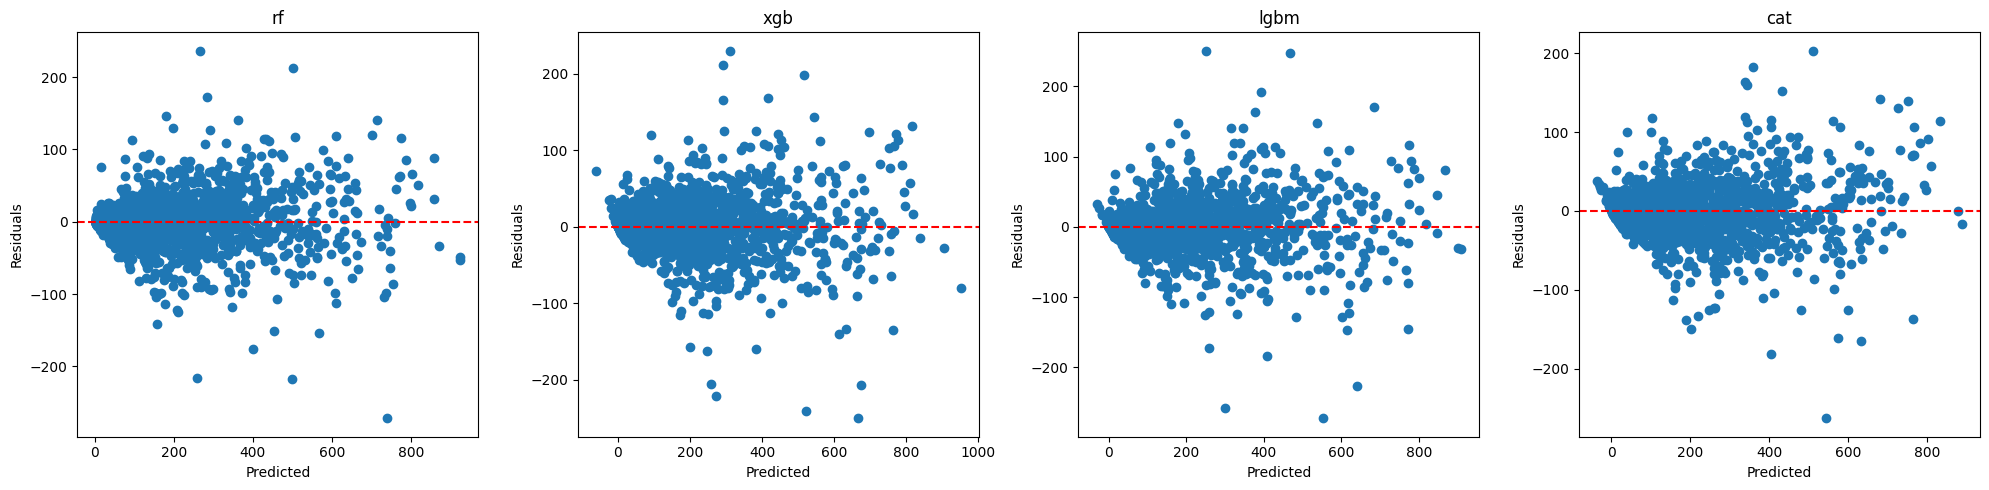

In [332]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  

residuals_rf = y_test - rf_pipeline.predict(x_test)
axes[0].scatter(rf_pipeline.predict(x_test), residuals_rf)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("rf")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_xgb = y_test - xgb_pipeline.predict(x_test)
axes[1].scatter(xgb_pipeline.predict(x_test), residuals_xgb)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("xgb")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_lgbm = y_test - lgbm_pipeline.predict(x_test)
axes[2].scatter(lgbm_pipeline.predict(x_test), residuals_lgbm)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("lgbm")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

residuals_cat = y_test - cat_pipeline.predict(x_test)
axes[3].scatter(cat_pipeline.predict(x_test), residuals_cat)
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_title("cat")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

----------------------------------------
----------------------------------------

### **To improve the performance of all models, and specifically to address this issue of heteroscedasticity, a logarithmic transformation to count of users**

--------------------------------

In [333]:
x_train, x_test, y2_train, y2_test = train_test_split(x, y_log, train_size=0.85, random_state=123)

In [334]:
r_2=[]
rmse=[]
mae=[]

def reg2(model):
    model.fit(x_train,y2_train)
    pred2 = model.predict(x_test)

    R2 = r2_score(y2_test,pred2)
    RMSE = sqrt(mean_squared_error(y2_test,pred2))
    MAE = mean_absolute_error(y2_test,pred2)
    
    r_2.append(R2)
    rmse.append(RMSE)
    mae.append(MAE)

In [335]:
reg2(rf_pipeline)
reg2(xgb_pipeline)
reg2(lgbm_pipeline)
reg2(cat_pipeline)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 225
[LightGBM] [Info] Number of data points in the train set: 9253, number of used features: 12
[LightGBM] [Info] Start training from score 4.588447


C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [336]:
Algorithms2 = ['RandomForestRegressor','XGBRegressor','LGBM_model','CatBoost_model']

In [337]:
result2 = pd.DataFrame({'Algorithms2':Algorithms2,'R2':r_2,'rmse':rmse,'mae':mae})
result2

,Algorithms2,R2,rmse,mae
0,RandomForestRegressor,0.952363,0.307920,0.203395
1,XGBRegressor,0.958837,0.286232,0.194345
2,LGBM_model,0.958956,0.285818,0.194842
3,CatBoost_model,0.964254,0.266737,0.179217


C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
C:\Users\RPC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


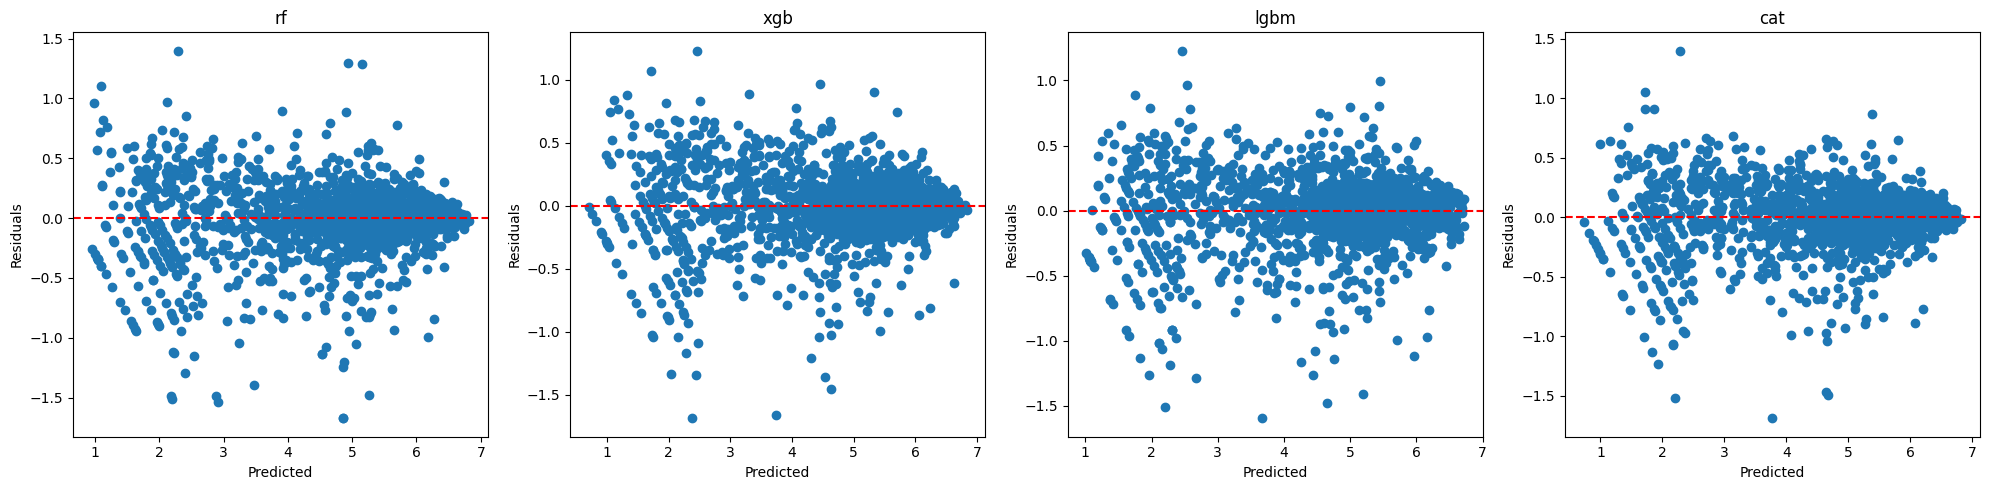

In [338]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))  

residuals_rf = y2_test - rf_pipeline.predict(x_test)
axes[0].scatter(rf_pipeline.predict(x_test), residuals_rf)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title("rf")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")

residuals_xgb = y2_test - xgb_pipeline.predict(x_test)
axes[1].scatter(xgb_pipeline.predict(x_test), residuals_xgb)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_title("xgb")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")

residuals_lgbm = y2_test - lgbm_pipeline.predict(x_test)
axes[2].scatter(lgbm_pipeline.predict(x_test), residuals_lgbm)
axes[2].axhline(y=0, color='red', linestyle='--')
axes[2].set_title("lgbm")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residuals")

residuals_cat = y2_test - cat_pipeline.predict(x_test)
axes[3].scatter(cat_pipeline.predict(x_test), residuals_cat)
axes[3].axhline(y=0, color='red', linestyle='--')
axes[3].set_title("cat")
axes[3].set_xlabel("Predicted")
axes[3].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

-------------------------------
-------------------------------
### **Testing Model**
-------------------------------

In [339]:
with open('cat_pipeline.pkl' , 'wb') as f :
     dump(cat_pipeline, f)

In [340]:
with open('cat_pipeline.pkl','rb') as f : 
    cat_pipeline = load(f)

In [341]:
new_data_test = pd.read_excel('data for test.xlsx')

In [342]:
original_new_data_test = new_data_test.copy()

In [343]:
df2.columns

Index(['season', 'holiday', 'workingday', 'weather', 'Actual_Temperature',
       'humidity', 'windspeed', 'count_of_users', 'year', 'month', 'day',
       'hour', 'the_usual_time_periods_per_day', 'weather_feeling',
       'is_workday_peak', 'is_weekend_peak'],
      dtype='object')

In [344]:
new_data_test = new_data_test[['season', 'holiday', 'workingday', 'weather', 'Actual_Temperature',
       'humidity', 'windspeed', 'count_of_users', 'year', 'month', 'day',
       'hour', 'the_usual_time_periods_per_day', 'weather_feeling']]

In [345]:
new_data_test.isnull().sum()

season                            0
holiday                           0
workingday                        0
weather                           0
Actual_Temperature                0
humidity                          0
windspeed                         0
count_of_users                    0
year                              0
month                             0
day                               0
hour                              0
the_usual_time_periods_per_day    0
weather_feeling                   0
dtype: int64

In [346]:
new_data_test = new_data_test.drop('count_of_users', axis=1)

In [ ]:
# workday_peaks = [7, 8, 9, 16, 17, 18, 19]
# new_data_test['is_workday_peak'] = ((new_data_test['workingday'] == 1) & (new_data_test['hour'].isin(workday_peaks))).astype(int)

# weekend_peaks = [10,11, 12, 13, 14, 15, 16, 17, 18]
# new_data_test['is_weekend_peak'] = ((new_data_test['workingday'] == 0) & (new_data_test['hour'].isin(weekend_peaks))).astype(int)

In [348]:
new_predictions = cat_pipeline.predict(new_data_test)

In [349]:
new_predictions = np.exp(new_predictions) 

In [350]:
original_new_data_test['Count Of Users Predicted'] = new_predictions

In [351]:
original_new_data_test['Count Of Users Predicted'] = original_new_data_test['Count Of Users Predicted'].apply(lambda x : round(x))

In [352]:
original_new_data_test.to_excel("bike rental test data prediction.xlsx", index=False)

In [354]:
pred_data = pd.read_excel('bike rental test data prediction.xlsx')
pred_data[['count_of_users','Count Of Users Predicted']]

,count_of_users,Count Of Users Predicted
0,37,33
1,36,42
2,34,40
3,28,29
4,39,35
...,...,...
91,308,327
92,189,237
93,167,139
94,60,55


## **Conclusion & Business Recommendations**
-----------------------------
#### **This project succeeded in building a comprehensive and highly accurate predictive system for bike-sharing demand, by combining rigorous statistical inference with advanced feature engineering and machine learning algorithms.**
----------------------------
- #### **Smart Fleet Redistribution: Implementing a dynamic supply plan that maximizes bike availability at key work locations between 7-9 AM and 4-7 PM midweek, and deploys them to recreational areas and parks throughout the afternoon (11 AM-6 PM) on weekends.**

- #### **Seasonal Maintenance Strategy: Taking advantage of the winter months and extended periods of high humidity to conduct comprehensive maintenance on the bikes, given the statistically proven decrease in demand during these times, and ensuring the fleet operates at full capacity during the summer.**

- #### **Dynamic Pricing: Launching incentive offers for occasional subscribers (tourists) during stable daytime hours midweek to stimulate activity compared to the weekend.**


In [ ]:
# !jupyter nbconvert --to html "Bike rental Prediction_project.ipynb"

[NbConvertApp] Converting notebook Bike rental Prediction_project.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 39 image(s).
[NbConvertApp] Writing 3617663 bytes to Bike rental Prediction_project.html
